# Lab 03: Is There a Planet in Your Light Curve?

**ASTR 457, Fall 2026, posted Thu Sep 17, due Wed Sep 23 by Noon (fork → PR, as always)**

*Why this lab: transit fitting by maximum likelihood is how thousands of planets, including every temperate world around an M dwarf that David Charbonneau will talk about at the Sep 29 colloquium, were actually measured, and the gap between an error bar computed the lazy way and one computed honestly is exactly the gap between a claim that survives referees and one that doesn't.*

Every one of you has your own dataset: `data/<your netid>.csv`, with columns `t_days`
(time from the start of a ~27-day TESS-style observing sector, 30-minute cadence, with a
~1-day data gap in the middle), `flux_rel` (relative flux, normalized near 1), and
`sigma_flux` (the per-point **white-noise** uncertainty). Your star is a nearby M dwarf
with a candidate transiting super-Earth. The light curve contains: the transit train,
slow instrumental systematics (drifts over days), and, as you will discover, noise
that is not entirely captured by `sigma_flux`. I know the true mid-transit time $t_0$,
period $P$, depth $\delta$, and duration $T$ for your dataset. You don't, you can't look
them up, and your classmates' planets are different from yours.

**How this is graded.** As always: on whether your answers are *right* and your
uncertainties are *honest*. Your reported depth and period are compared to your truth in
units of your own reported uncertainty. Anti-sandbagging cap: your $\sigma_\delta$ may
not exceed 3× a reference uncertainty I compute for your dataset; defensive error bars
lose points just like overconfident ones.

**AI policy reminder.** Use whatever tools you like, including AI assistants, and
document it in Part 4. You may be selected to defend this lab in person (the practice
round was Sep 15; the real ones use the same format).

## The transit model (given)

Use this five-parameter periodic trapezoid, the small-planet limit of Mandel & Agol
(2002), the same model from Tuesday's lecture. The parameters are
$\theta = (t_0, P, \delta, T, F_0)$: mid-transit time of the first transit, period,
depth, total duration, and out-of-transit baseline flux. Ingress and egress each span
20% of the duration.

In [712]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

def transit_model(t, t0, period, depth, duration, baseline, ingress_frac=0.2):
    """Periodic trapezoidal transit train."""
    ph = ((t - t0 + 0.5 * period) % period) - 0.5 * period
    half = duration / 2.
    ing = ingress_frac * duration
    f = np.ones_like(t)
    inside = np.abs(ph) < half
    full = np.abs(ph) < (half - ing)
    f[inside] = 1. - depth * np.clip((half - np.abs(ph[inside])) / ing, 0., 1.)
    f[full] = 1. - depth
    return baseline * f

NETID = 'benh7'  # <-- set this
d = np.genfromtxt(f'data/{NETID}.csv', delimiter=',', names=True, skip_header=1)
t, flux, sigma = d['t_days'], d['flux_rel'], d['sigma_flux']
print(f'{len(t)} points spanning {t[-1]:.1f} days; stated sigma = {sigma[0]*1e3:.2f} ppt')

1263 points spanning 27.4 days; stated sigma = 1.10 ppt


## Part 1: Find the planet (20%)

1. Plot the raw light curve. Identify the slow systematic trend and the transits.
2. **Detrend** the light curve. Be deliberate: state your method (median filter, spline,
   polynomial per segment, your choice), your smoothing scale, and *why that scale
   can't eat your transits*. Plot raw, trend, and detrended flux.
3. From the detrended curve, read off by eye: approximate $t_0$, $P$, depth, duration:
   your initial guesses for Part 2.
4. Compare the out-of-transit scatter of your detrended flux to the stated `sigma_flux`.
   Are they consistent? Say what you conclude (a sentence is fine, and you'll need this
   observation in Parts 2 and 3).

Text(0, 0.5, '% Flux')

<Figure size 640x480 with 0 Axes>

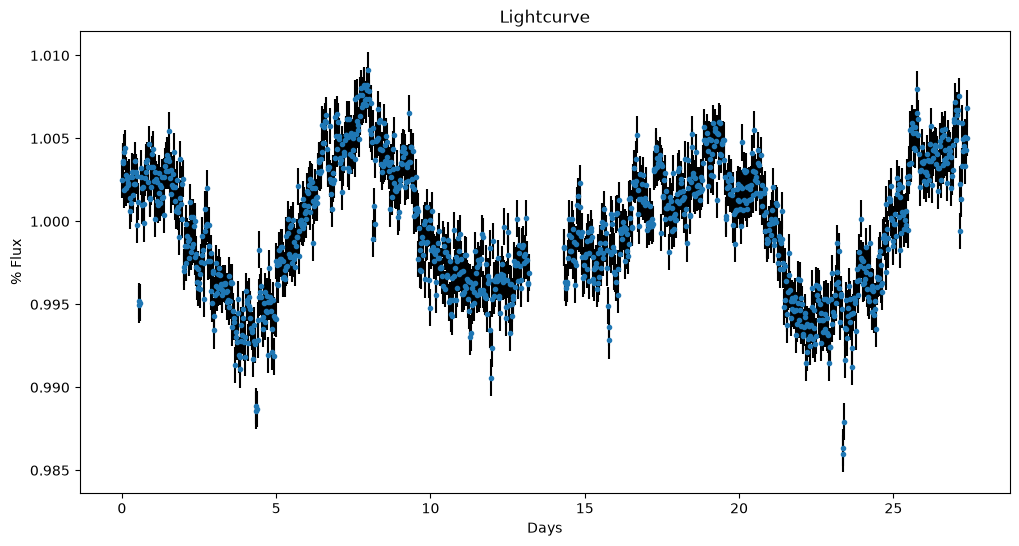

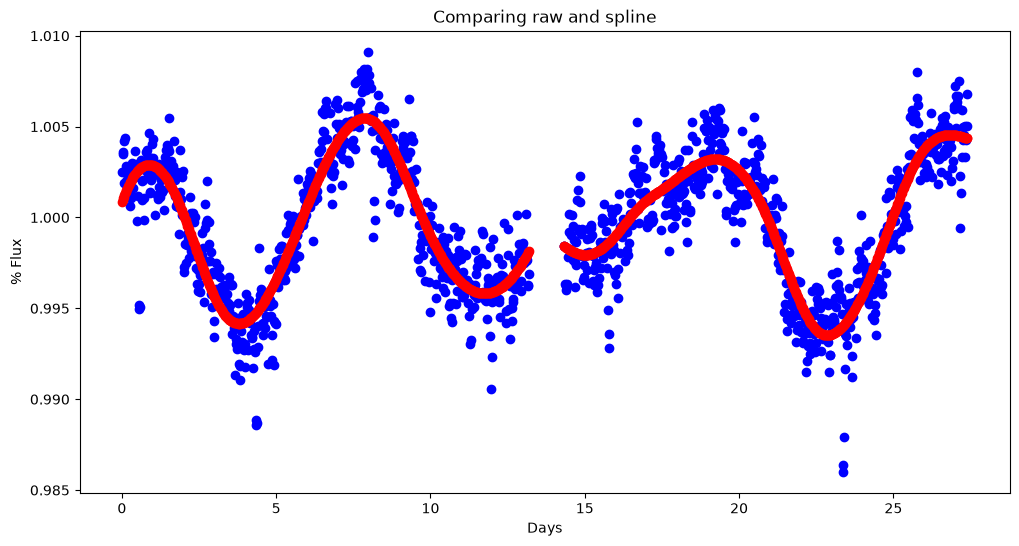

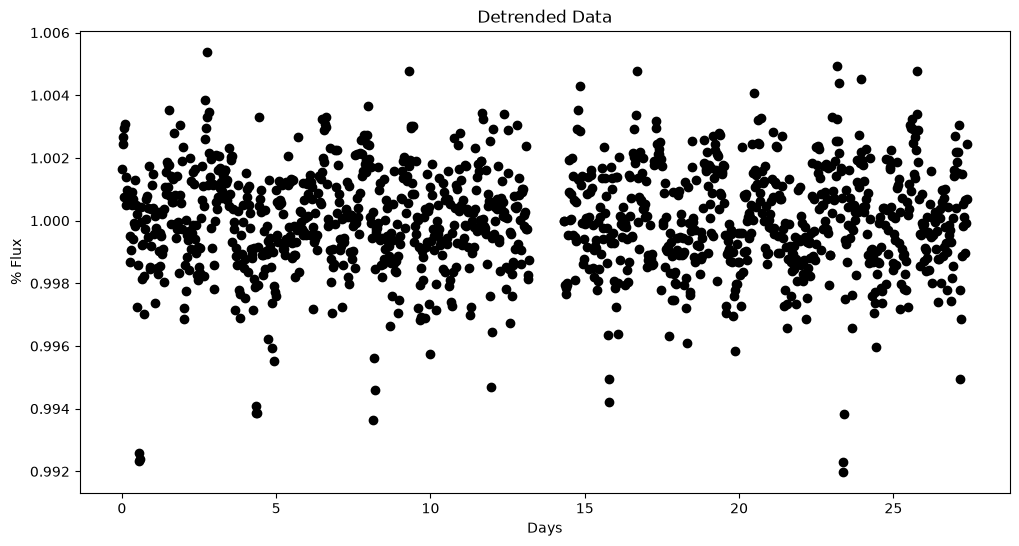

In [777]:
# Part 1: your work here
import scipy

plt.figure(1)
plt.figure(figsize = (12, 6))
plt.errorbar(t, flux, yerr = sigma, ecolor = 'black', fmt = '.')
plt.xlabel('Days')
plt.ylabel('% Flux')
plt.title('Lightcurve')

from scipy.interpolate import UnivariateSpline

t1 = t[:634]
f1 = flux[:634]
sigma1 = sigma[:634]

t2 = t[634:]
f2 = flux[634:]
sigma2 = sigma[634:]

spline1 = UnivariateSpline(t1, f1, w=1/sigma1, s=1500)
trend1 = spline1(t1)

spline2 = UnivariateSpline(t2, f2, w=1/sigma2, s=1500)
trend2 = spline2(t2)

plt.figure(2)
plt.figure(figsize = (12, 6))
plt.scatter(t, flux, color = 'blue', label = 'raw data')
plt.scatter(t1, trend1, color = 'red', label = 'spline')
plt.scatter(t2, trend2, color = 'red', label = 'spline')
plt.title('Comparing raw and spline')
plt.xlabel('Days')
plt.ylabel('% Flux')

plt.figure(3)
plt.figure(figsize = (12, 6))
plt.scatter(t1, f1 - trend1 + 1, color = 'black')
plt.scatter(t2, f2 - trend2 + 1, color = 'black')
plt.title('Detrended Data')
plt.xlabel('Days')
plt.ylabel('% Flux')

I chose a spline to detrend my data. I chose this method as it allowed me to create a curve that followed the trends of my data, without erasing any of the prior information (such as in the median detrend). By manually tweaking the size of the fit, I could fit a curve to the slow systamatic trend, without inducing overfitting to my data by allowing for more curves than the large scale structure. By manually tweaking this model until it matched the noise inducing multi-day periods, I could remove this longer noise. Additionally, since I could manually see that this spline had a period with a length of multiple days, I knew that it would have to have a curve length magnitudes longer than a transit period (which should be on the order of hours). This longer length would prevent the fine details from getting smoothed out when I detrended the data.

0.541667
0.5625
2.0
4.333333
4.354167
8.145833
8.166667
9.958333
11.291667
11.958333
15.75
15.770833
19.5625
23.354167
23.375
27.166667


(0.992, 0.997)

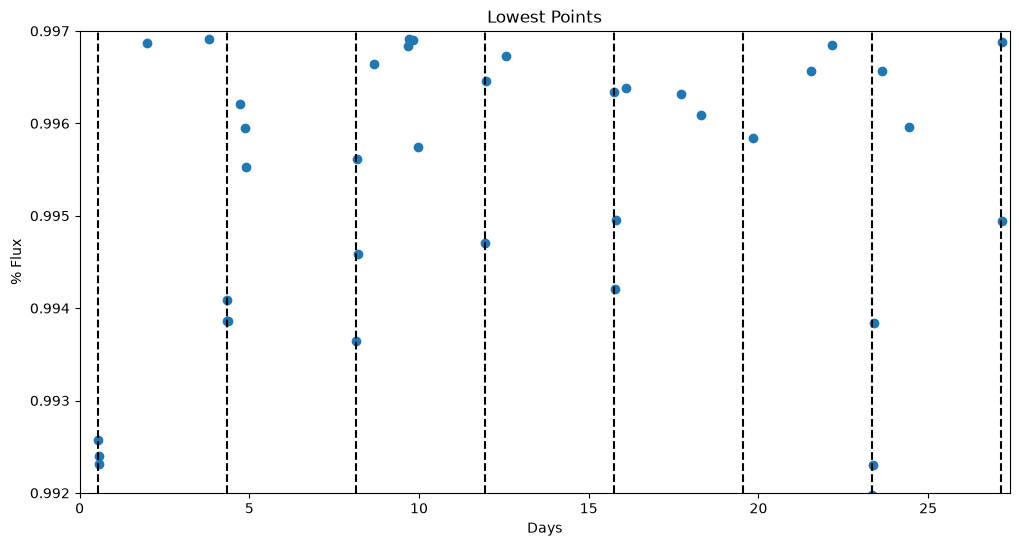

In [778]:
detrend = np.concatenate([f1 - trend1 + 1, f2 - trend2 + 1])

low = detrend < np.percentile(detrend, 5)

for i in range(len(detrend) - 2):
    if (low[i]) & (low[i+1]): #& (low[i + 2]): #& low[i+2]:
        print(t[i])


cut = np.percentile(detrend, 3)
locs = np.where(detrend < cut)

plt.figure(figsize = (12, 6))
plt.scatter(t[locs], detrend[locs])
plt.xlim([0, 27.4])

plt.xlabel('Days')
plt.ylabel('% Flux')
plt.title('Lowest Points')

val = .542

while val < 28:
    plt.vlines(val, ymin = .992, ymax = 1, color = 'black', linestyle = '--')
    val += 3.8

plt.ylim([.992, .997])

(0.992, 1.006)

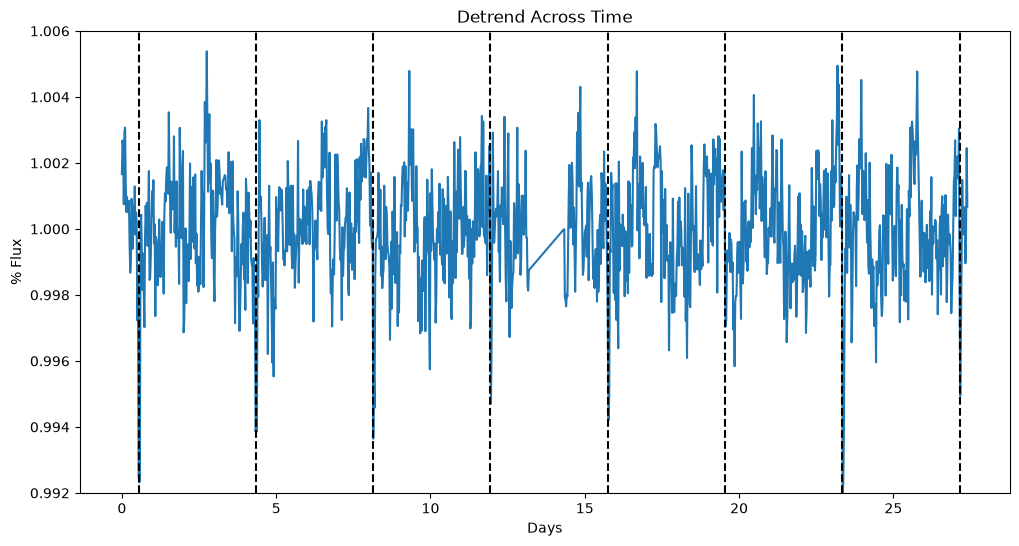

In [779]:
plt.figure(figsize = (12, 6))
plt.plot(t, detrend)
plt.xlabel('Days')
plt.ylabel('% Flux')
plt.title('Detrend Across Time')

val = .542

while val < 28:
    plt.vlines(val, ymin = .992, ymax = 1.1, color = 'black', linestyle = '--')
    val += 3.8

plt.ylim([.992, 1.006])

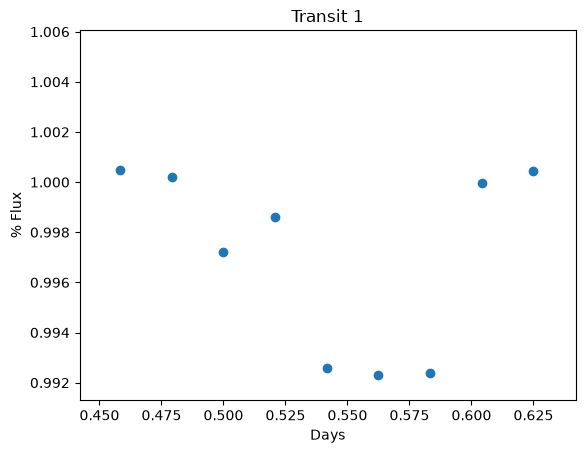

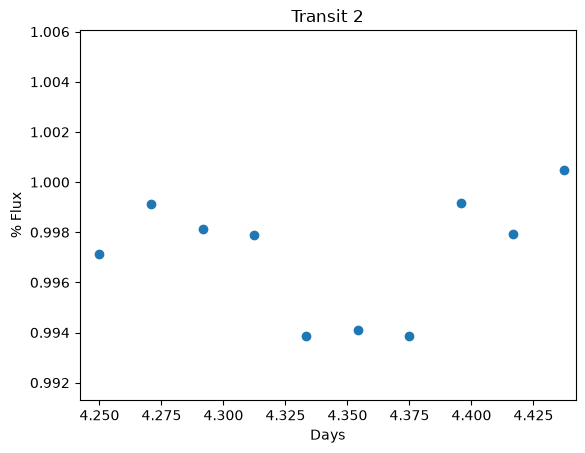

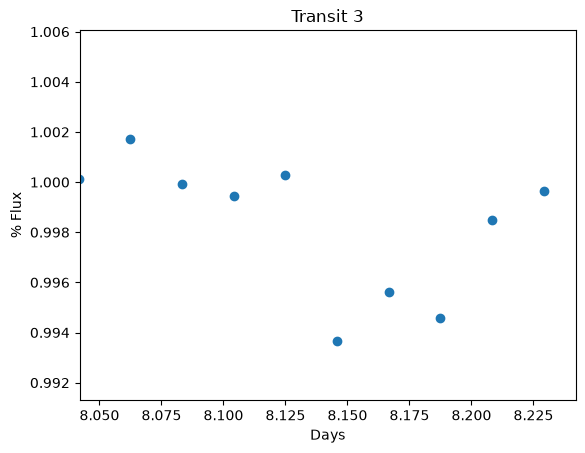

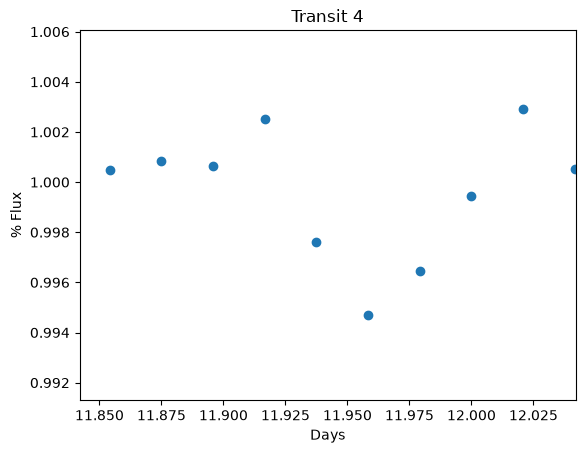

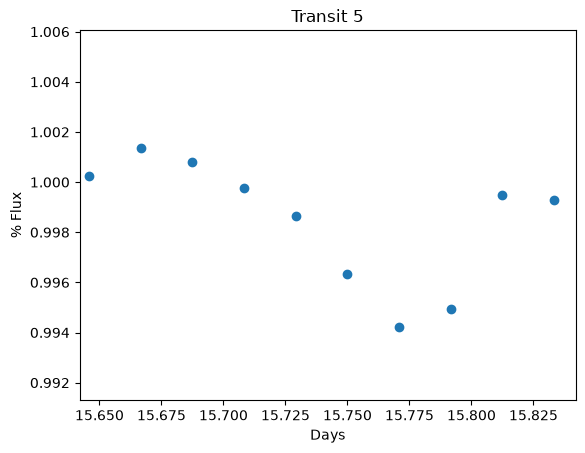

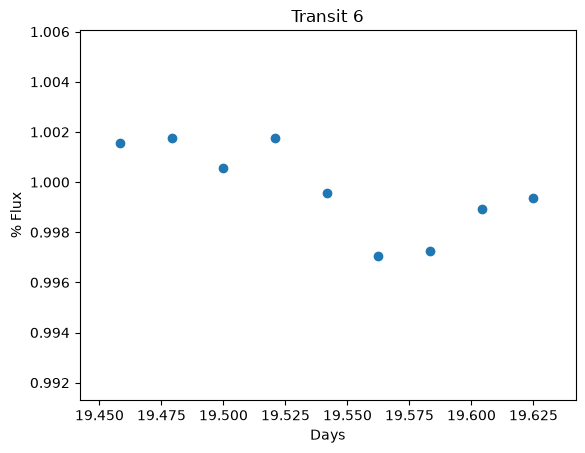

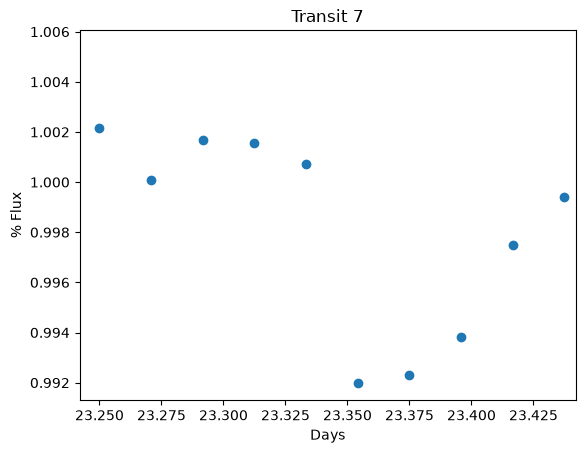

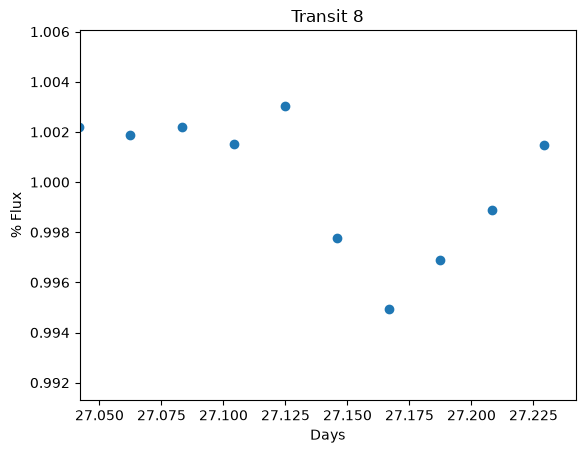

In [780]:
val = .542
count = 1
while val < 28:
    plt.figure(count)
    plt.title(f'Transit {count}')
    plt.xlabel('Days')
    plt.ylabel('% Flux')
    plt.scatter(t, detrend)
    plt.xlim([val - .1, val + .1])
    count += 1
    val += 3.8

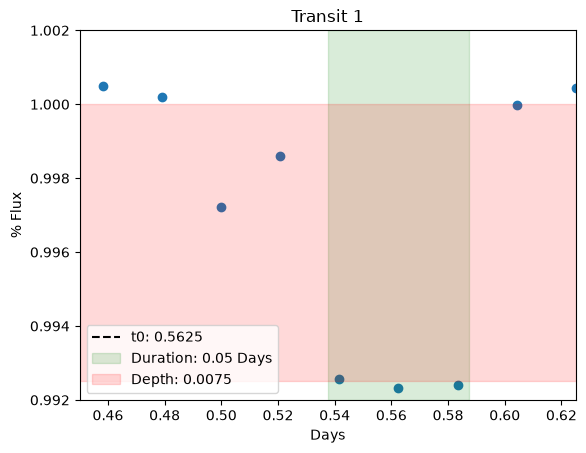

In [781]:
plt.title(f'Transit 1')
plt.xlabel('Days')
plt.ylabel('% Flux')
plt.scatter(t, detrend)
plt.xlim([.45, .625])

plt.vlines(.5625, ymin = -.008, ymax = .002, color = 'black', linestyle = '--', label = f't0: {.5625}')
plt.axvspan(.5375, .5875, color = 'green', alpha = .15, label = f'Duration: {.05} Days')
plt.axhspan(1, .9925, color = 'red', alpha = .15, label = f'Depth: {.0075}')
plt.ylim([.992, 1.002])

plt.legend()

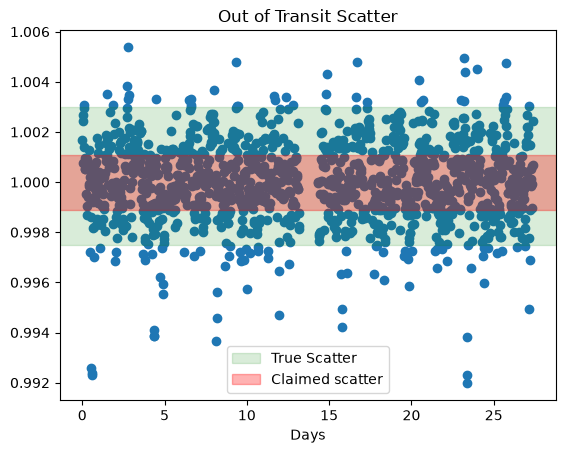

In [883]:
plt.scatter(t, detrend)
plt.title('Out of Transit Scatter')
plt.xlabel('Days')
plt.ylabel('')
plt.axhspan(1.003, .9975, color = 'Green', alpha = .15, label = 'True Scatter')
plt.axhspan(1 + sigma[0], 1 - sigma[0], color = 'red', alpha = .3, label = 'Claimed scatter')

plt.legend()

My out of transit scatter is much larger than the actual scatter of my data. With this, I can conclude that the stated sigma scattering is underreported and that I should not trust these claimed errors. 

In [783]:
t0_guess = .5625
P_guess = 3.8
depth_guess = .0075
duration_guess = .05

**ANSWERS (initial guesses + scatter check):**

T0: .5625 Days

P: 3.8 Days

Depth: 7500 ppm

Duration: 1.2 hrs

Scatter: .0014

## Part 2: The measurement you'd publish (40%)

1. Write the Gaussian log-likelihood for the transit model and maximize it
   (`scipy.optimize.minimize`; Nelder-Mead first, as in lecture). Fit all five
   parameters. Plot the phase-folded data with your best-fit model, and the residuals.
2. Estimate uncertainties **two ways**:
   - from the curvature of the log-likelihood at the maximum (the inverse Hessian,
     lecture method), and
   - by **bootstrap**, and think about *what* you resample: if you resample individual
     points, what are you assuming about the noise? A block bootstrap (resample
     contiguous chunks of residuals, e.g. 1-day blocks) makes a different assumption.
     Do both point-wise and block versions and compare.
3. The three uncertainty estimates for the depth will not all agree. Explain the pattern
   using your Part 1 scatter observation. Which noise property do the Hessian and the
   point-wise bootstrap both assume that your residuals violate? Demonstrate that
   violation with a plot or a number (hint: bin your residuals in ~5-hour bins and
   compare the binned scatter to what independent noise predicts).
4. **Commit to final answers**: $\delta \pm \sigma_\delta$, $P \pm \sigma_P$,
   $t_0 \pm \sigma_{t_0}$, and justify which uncertainty estimate you adopted.

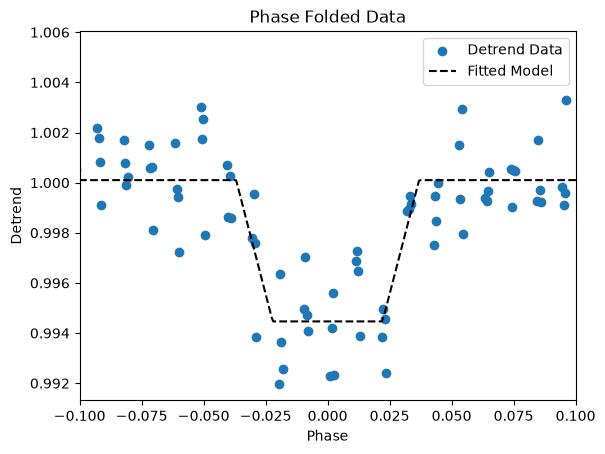

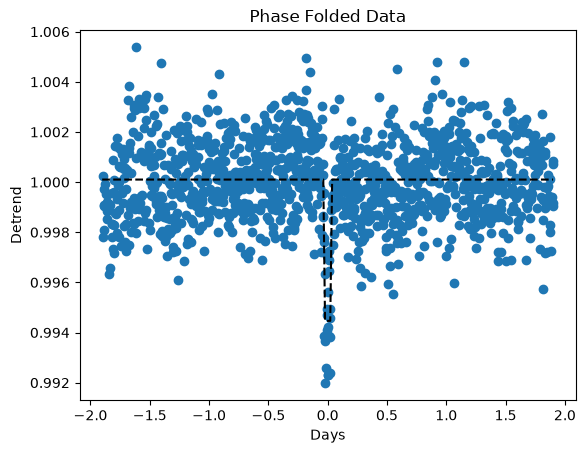

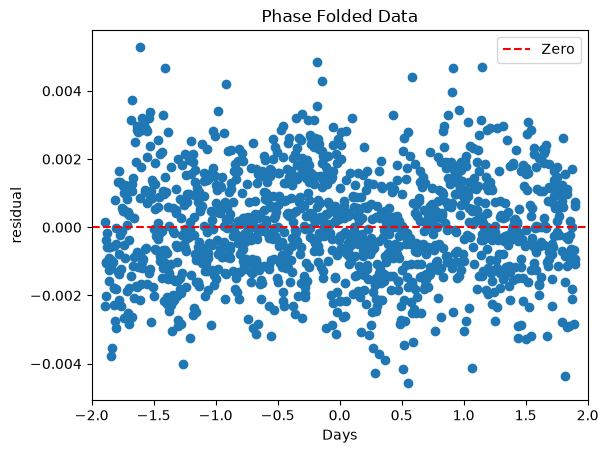

In [1004]:
# Part 2: your work here
from scipy.optimize import minimize
from scipy.stats import norm
import numdifftools as nd

def neg_log_likelihood(theta, x, y, sigma):
    t0, P0, Depth0, Duration0, baseline0 = theta
    model = transit_model(x, t0, P0, Depth0, Duration0, baseline0, ingress_frac=0.2)
    g_liklihoods = ((y - model)/sigma)**2 + np.log(2 * np.pi * sigma**2)
    return .5 * np.sum(g_liklihoods)

theta0 = [.5625, 3.8, .0075, .05, 1.0]
result = minimize(neg_log_likelihood, theta0, args=(t, detrend, sigma), method='Nelder-Mead')
t0_opt, P_opt, Depth_opt, Duration_opt, baseline_opt = result.x
result_opt = result.x

model_opt = transit_model(t, t0_opt, P_opt, Depth_opt, Duration_opt, baseline_opt, ingress_frac=0.2)


plt.figure(1)

phase = ((t - t0_opt + .5 * P_opt) % P_opt) - 0.5 * P_opt

idx = np.argsort(phase)
phase_sort = phase[idx]
flux_sort = detrend[idx]
model_sort = model_opt[idx]

plt.scatter(phase_sort, flux_sort, label = 'Detrend Data')
plt.plot(p_sort, m_sort, color = 'black', linestyle = '--', label = 'Fitted Model')
plt.title('Phase Folded Data')
plt.xlabel('Phase')
plt.ylabel('Detrend')
plt.xlim([-.1, .1])
plt.legend()

plt.figure(2)

plt.scatter(phase_sort, flux_sort, label = 'Detrend Data')
plt.plot(p_sort, m_sort, color = 'black', linestyle = '--', label = 'Fitted Model')
plt.title('Phase Folded Data')
plt.xlabel('Days')
plt.ylabel('Detrend')



plt.figure(3)
residual = flux_sort - model_sort
plt.scatter(phase_sort, residual)
plt.title('Phase Folded Data')
plt.xlabel('Days')
plt.ylabel('residual')
plt.hlines(0, xmin = -2, xmax = 2, color = 'red', linestyle = '--', label = 'Zero')
plt.xlim([-2, 2])
plt.legend()

In [956]:
print(f'Optimized Model Parameters: {result_opt}')

Optimized Model Parameters: [0.55973185 3.80235521 0.00563419 0.07381289 1.00010211]


In [850]:
H = nd.Hessian(lambda th: neg_log_likelihood(th, t, detrend, sigma), step = 1e-6)(theta_opt)
cov = np.linalg.inv(H)
unc = np.sqrt(np.diag(cov))

print(f' To unc: {unc[0]:.6f}')
print(f' P unc: {unc[1]:.6f}')
print(f' Depth unc: {unc[2]:.6f}')
print(f' Duration unc: {unc[3]:.6f}')
print(f' Baseline unc: {unc[4]:.6f}')

 To unc: 0.001644
 P unc: 0.000388
 Depth unc: 0.000260
 Duration unc: 0.002427
 Baseline unc: 0.000031


In [789]:
t0_boot_a = np.zeros(2000)
P_boot_a = np.zeros(2000)
Depth_boot_a = np.zeros(2000)
Duration_boot_a = np.zeros(2000)
Baseline_boot_a = np.zeros(2000)

for i in range(2000):

    resampled_residuals = np.random.choice(residual, len(residual), replace = True)
    flux_boot = model_opt + resampled_residuals

    boot_result = minimize(neg_log_likelihood, theta0, args=(t, flux_boot, sigma), method='Nelder-Mead')
    t0_boot, P_boot, Depth_boot, Duration_boot, baseline_boot = boot_result.x

    t0_boot_a[i] = t0_boot
    P_boot_a[i] = P_boot
    Depth_boot_a[i] = Depth_boot
    Duration_boot_a[i] = Duration_boot
    Baseline_boot_a[i] = baseline_boot

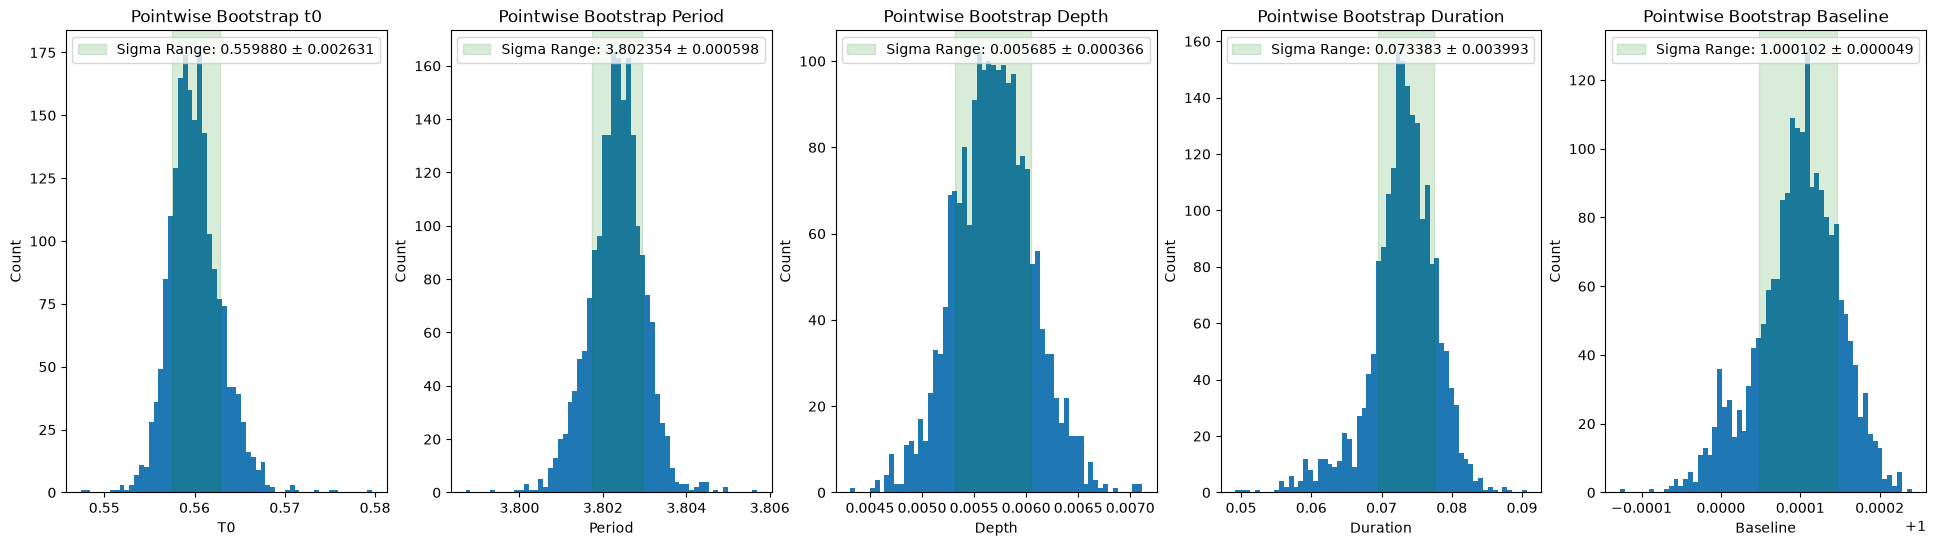

In [790]:
plt.figure(figsize = (24, 6))
plt.subplot(1, 5, 1)
plt.hist(t0_boot_a, bins = 60)

lo_t0, hi_t0 = np.percentile(t0_boot_a, [16, 84])
pw_t0_s = (hi_t0 - lo_t0)/2
plt.axvspan(lo_t0, hi_t0, color = 'green', alpha = .15, label = f'Sigma Range: {np.median(t0_boot_a):.6f} \u00B1 {pw_t0_s:.6f}')

plt.title('Pointwise Bootstrap t0')
plt.xlabel('T0')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 5, 2)
plt.hist(P_boot_a, bins = 60)

lo_P, hi_P = np.percentile(P_boot_a, [16, 84])
pw_P_s = (hi_P - lo_P)/2
plt.axvspan(lo_P, hi_P, color = 'green', alpha = .15, label = f'Sigma Range: {np.median(P_boot_a):.6f} \u00B1 {pw_P_s:.6f}')

plt.title('Pointwise Bootstrap Period')
plt.xlabel('Period')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 5, 3)
plt.hist(Depth_boot_a, bins = 60)


lo_Dep, hi_Dep = np.percentile(Depth_boot_a, [16, 84])
pw_Dep_s = (hi_Dep - lo_Dep)/2
plt.axvspan(lo_Dep, hi_Dep, color = 'green', alpha = .15, label = f'Sigma Range: {np.median(Depth_boot_a):.6f} \u00B1 {pw_Dep_s:.6f}')

plt.title('Pointwise Bootstrap Depth')
plt.xlabel('Depth')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 5, 4)
plt.hist(Duration_boot_a, bins = 60)

lo_Dur, hi_Dur = np.percentile(Duration_boot_a, [16, 84])
pw_Dur_s = (hi_Dur - lo_Dur)/2
plt.axvspan(lo_Dur, hi_Dur, color = 'green', alpha = .15, label = f'Sigma Range: {np.median(Duration_boot_a):.6f} \u00B1 {pw_Dur_s:.6f}')

plt.title('Pointwise Bootstrap Duration')
plt.xlabel('Duration')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 5, 5)
plt.hist(Baseline_boot_a, bins = 60)

lo_bas, hi_bas = np.percentile(Baseline_boot_a, [16, 84])
pw_bas_s = (hi_bas - lo_bas)/2

plt.axvspan(lo_bas, hi_bas, color = 'green', alpha = .15, label = f'Sigma Range: {np.median(Baseline_boot_a):.6f} \u00B1 {pw_bas_s:.6f}')

plt.title('Pointwise Bootstrap Baseline')
plt.xlabel('Baseline')
plt.ylabel('Count')
plt.legend()

In [791]:
blocks = []

for i in range(27):
    blocks.append(residual[48*i : 48*i + 48])

In [792]:
t0_block_boot_a = np.zeros(2000)
P_block_boot_a = np.zeros(2000)
Depth_block_boot_a = np.zeros(2000)
Duration_block_boot_a = np.zeros(2000)
Baseline_block_boot_a = np.zeros(2000)

for i in range(2000):

    block_data = []
    
    while len(block_data) < 1263:
        r = np.random.randint(0, len(blocks))
        block_data.extend(blocks[r])
    
    block_array = np.array(block_data)
    flux_block_boot = model_opt + block_array[:1263]
    
    block_boot_result = minimize(neg_log_likelihood, theta0, args=(t, flux_block_boot, sigma), method='Nelder-Mead')
    t0_block_boot, P_block_boot, Depth_block_boot, Duration_block_boot, baseline_block_boot = block_boot_result.x
    
    t0_block_boot_a[i] = t0_block_boot
    P_block_boot_a[i] = P_block_boot
    Depth_block_boot_a[i] = Depth_block_boot
    Duration_block_boot_a[i] = Duration_block_boot
    Baseline_block_boot_a[i] = baseline_block_boot

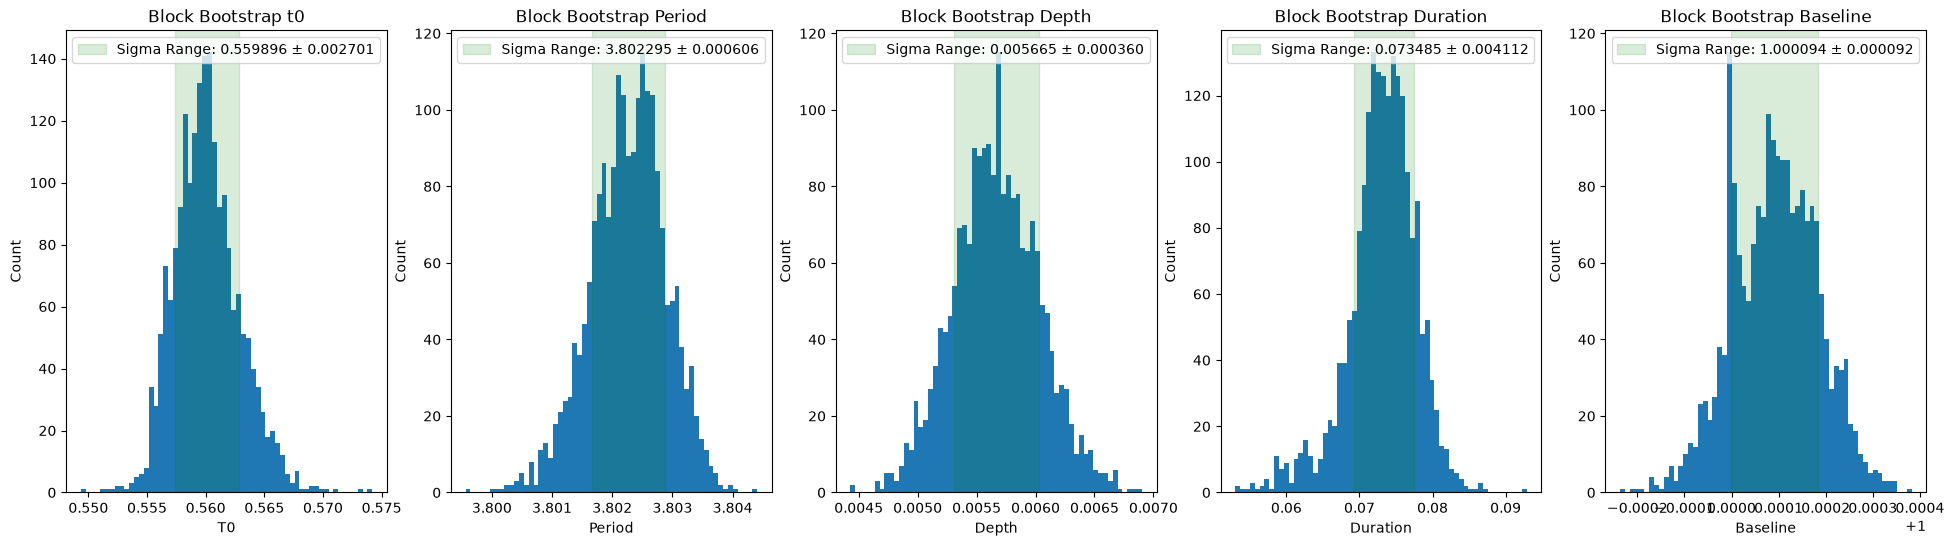

In [793]:
plt.figure(figsize = (24, 6))
plt.subplot(1, 5, 1)
plt.hist(t0_block_boot_a, bins = 60)

lo_t0_block, hi_t0_block = np.percentile(t0_block_boot_a, [16, 84])
pw_t0_block_s = (hi_t0_block - lo_t0_block)/2
plt.axvspan(lo_t0_block, hi_t0_block, color = 'green', alpha = .15, label = f'Sigma Range: {np.median(t0_block_boot_a):.6f} \u00B1 {pw_t0_block_s:.6f}')

plt.title('Block Bootstrap t0')
plt.xlabel('T0')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 5, 2)
plt.hist(P_block_boot_a, bins = 60)

lo_P_block, hi_P_block = np.percentile(P_block_boot_a, [16, 84])
pw_P_block_s = (hi_P_block - lo_P_block)/2
plt.axvspan(lo_P_block, hi_P_block, color = 'green', alpha = .15, label = f'Sigma Range: {np.median(P_block_boot_a):.6f} \u00B1 {pw_P_block_s:.6f}')

plt.title('Block Bootstrap Period')
plt.xlabel('Period')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 5, 3)
plt.hist(Depth_block_boot_a, bins = 60)


lo_Dep_block, hi_Dep_block = np.percentile(Depth_block_boot_a, [16, 84])
pw_Dep_block_s = (hi_Dep_block - lo_Dep_block)/2
plt.axvspan(lo_Dep_block, hi_Dep_block, color = 'green', alpha = .15, label = f'Sigma Range: {np.median(Depth_block_boot_a):.6f} \u00B1 {pw_Dep_block_s:.6f}')

plt.title('Block Bootstrap Depth')
plt.xlabel('Depth')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 5, 4)
plt.hist(Duration_block_boot_a, bins = 60)

lo_Dur_block, hi_Dur_block = np.percentile(Duration_block_boot_a, [16, 84])
pw_Dur_block_s = (hi_Dur_block - lo_Dur_block)/2
plt.axvspan(lo_Dur_block, hi_Dur_block, color = 'green', alpha = .15, label = f'Sigma Range: {np.median(Duration_block_boot_a):.6f} \u00B1 {pw_Dur_block_s:.6f}')

plt.title('Block Bootstrap Duration')
plt.xlabel('Duration')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 5, 5)
plt.hist(Baseline_block_boot_a, bins = 60)

lo_bas_block, hi_bas_block = np.percentile(Baseline_block_boot_a, [16, 84])
pw_bas_block_s = (hi_bas_block - lo_bas_block)/2
plt.axvspan(lo_bas_block, hi_bas_block, color = 'green', alpha = .15, label = f'Sigma Range: {np.median(Baseline_block_boot_a):.6f} \u00B1 {pw_bas_block_s:.6f}')

plt.title('Block Bootstrap Baseline')
plt.xlabel('Baseline')
plt.ylabel('Count')
plt.legend()

In [836]:
r_blocks = []
r_avg = []

for i in range(126):
    chunk = residual[10*i : 10*i + 10]
    r_blocks.append(chunk)
    r_avg.append(np.mean(chunk))


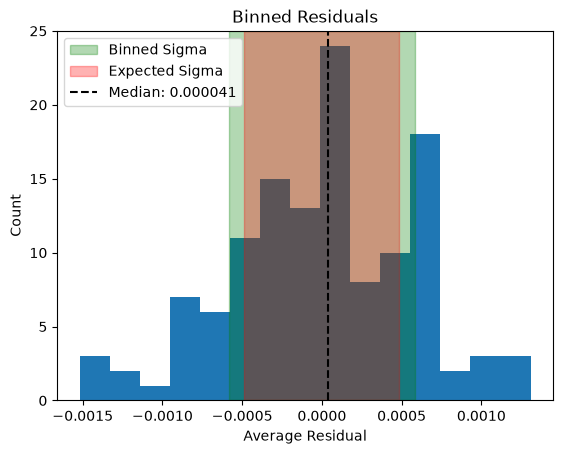

In [837]:
r_i_std = np.std(residual)

expected_sigma = r_i_std/np.sqrt(10)
binned_sigma = np.std(r_avg)
r_avg_med = np.median(r_avg)

plt.hist(r_avg, bins = 15)
plt.title('Binned Residuals')
plt.xlabel('Average Residual')
plt.ylabel('Count')

plt.axvspan(-binned_sigma, binned_sigma, color = 'green', alpha = .3, label = 'Binned Sigma')
plt.axvspan(-expected_sigma, expected_sigma, color = 'red', alpha = .3, label = 'Expected Sigma')
plt.vlines(r_avg_med, ymin = 0, ymax = 25, color = 'black', linestyle = '--', label = f'Median: {r_avg_med:.6f}')
plt.ylim([0, 25])

plt.legend()

The Hessian and pointwise assume scatter is independent of other points. As binned sigma is larger than expected sigma, points are correlated with each other and this is not a valid assumption. 

In [838]:
print(f'Optimized Model Parameters: {result_opt}')

Optimized Model Parameters: [0.55973185 3.80235521 0.00563419 0.07381289 1.00010211]


**FINAL ANSWER:** $\delta = $ 5635 * 10^6 $\pm$ 2593 * 10^6 ppt, $P = 3.802358$  $\pm$ .000622 d, $t_0 = $ .559713 $\pm$ .000377 d

**Which uncertainty and why (a short paragraph):**

*I used the uncertainties calculated from my block bootstrap. Since my observed sigma from my binned histogram is larger than the expected sigma of an indipendent observation, the scatter of a binned group is larger than would be expected for if every point is independent of each other. For this reason, I chose to adopt my block bootstrap uncertainties. Since my block bootstrap takes chunks of data that are a day long (which is much longer than my transit length) it takes the longterm trends of the timeseries into consideration. Using the Hessian or the pointwise uncertainties would bias my data as these assume there is no longterm correlation.*

## Part 3: The referee report (30%)

The file `ai_solution.ipynb` in this directory is a complete, tidy, confident analysis
of this exact problem, produced by an AI assistant. It runs top to bottom without
errors, the phase-folded plot looks professional, and the prose is fluent. It is also
wrong, in at least **three** distinct, substantive ways (cosmetic nitpicks don't
count).

Write a referee report:

1. **Identify** at least three substantive statistical errors.
2. **Demonstrate** each one quantitatively on *your* dataset. Show, with a number or a
   plot, what the error does to the inference. "This is bad practice" is not a
   demonstration.
3. **State** what the correct treatment is (you already built it in Part 2).

You've done this once before, on Lab 01. Notice how much faster you are at it now.
That speed is the skill this course is building.

**REFEREE REPORT:**

*Flaw 1: In part 1, the Ai uses a median filter that is overfit. This will smooth over the transit.*

*Flaw 2: In part 2, Ai calculates the out of transit noise using the detrend. This will create a larger expected sigma value.*

*Flaw 3: In part 4, the Ai uses the Hessian to calculate the uncertainties. This assumes the data is uncorrelated between points.*

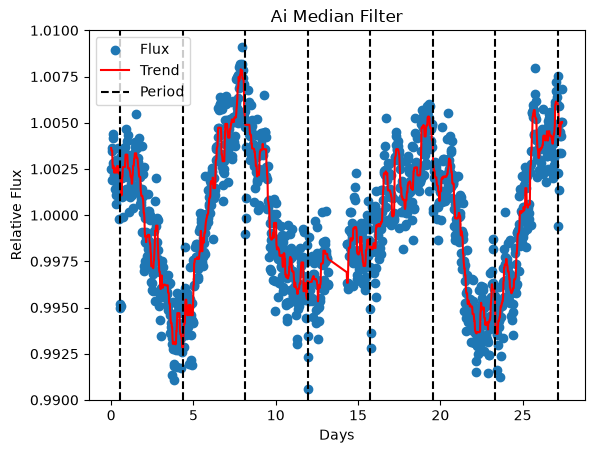

In [839]:
# Part 3: demonstrations here
#Flaw 1:
from scipy.ndimage import median_filter

cadence = np.median(np.diff(t))
window = max(3, int(round((6.0 / 24.) / cadence)))
trend = median_filter(flux, size=window)
flux_detrended = flux - trend + 1.0

plt.scatter(t, flux, label = 'Flux')
plt.plot(t, trend, color = 'red', label = 'Ai Trend')

plt.xlabel('Days')
plt.ylabel('Relative Flux')
plt.title('Ai Median Filter')
plt.ylim([.99, 1.01])

val = .542

while val < 28:
    plt.vlines(val, ymin = .99, ymax = 1.1, color = 'black', linestyle = '--')
    val += 3.8

plt.legend(['Flux', 'Trend', 'Period'])


This filter that the Ai is using is overfit. This causes the trend line to follow both the longterm systamatic trend as well as the shorterm changes. When you plot the period ontop of the Ai's trend, dips in the Ai trend align with the periods. This means that the median filter is picking up the change in flux from the transit itself and eating. This will change the transit properties as part of their trend will be subtracted out. When fitting the data later, this bit that was subtracted out will be missing causing the parameters found to be different from the actual transit.

In [840]:
#Flaw 2:
sigma_emp = np.std(flux_detrended)
print(f"Empirical per-point noise: {sigma_emp*1e3:.3f} ppt")
print("Using the empirical scatter makes the analysis robust to any")
print("misreported pipeline uncertainties.")

Empirical per-point noise: 1.338 ppt
Using the empirical scatter makes the analysis robust to any
misreported pipeline uncertainties.


To calculate the out of transit noise, the Ai is directly taking the standard deviation of detrend. This deviation isn't the deviation of just the noise. It still includes the shape of the transits within the data. This will drive up the standard deviation and make it seem larger than it should be. 

Text(0, 0.5, 'Standard Deviation')

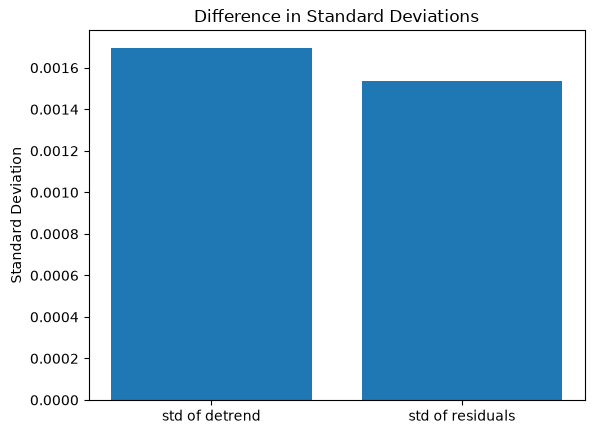

In [854]:
detrend_std = np.std(detrend)
plt.bar(['std of detrend', 'std of residuals'], [detrend_std, r_i_std])
plt.title('Difference in Standard Deviations')
plt.ylabel('Standard Deviation')

The proper handling of this is to use the deviation of the residuals. By removing the shape of the model (and by extention the large deviations caused by the transits) the deviation of the out of transit noise will actually only take only the scatter of noise into consideration rather than the scatter + the transits into consideration.

Text(0, 0.5, 'Standard Deviation')

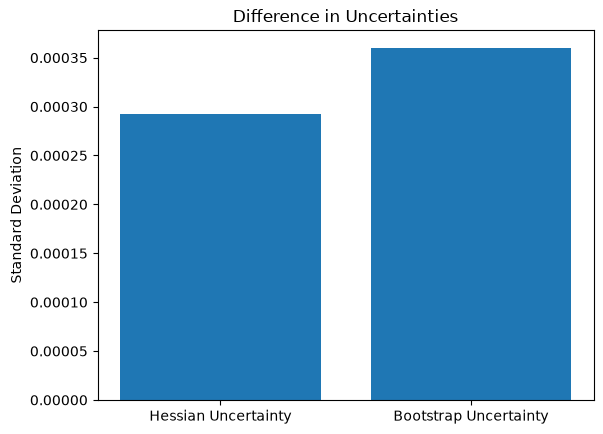

In [862]:
#Flaw 3:
depth_fit = result_opt[2]

h = depth_fit * 1e-3
def nll_d(dd):
    th = result_opt.copy(); th[2] = dd
    return neg_log_likelihood(th, t, flux_detrended, sigma_emp)
curv = (nll_d(depth_fit + h) - 2 * nll_d(depth_fit) + nll_d(depth_fit - h)) / h**2
sigma_depth = 1.0 / np.sqrt(curv)

plt.bar(['Hessian Uncertainty', 'Bootstrap Uncertainty'], [sigma_depth, .00036])
plt.title('Difference in Uncertainties')
plt.ylabel('Standard Deviation')

The Ai model uses the Hessian to calculate the uncertainty of the data. As we showed however, individual points are correlated. Using the Hessian to calcualte the uncertainty within the data assumes that there is no correlation between points. As this is not the case, the hessian reports a biased uncertainty that misrepresents the true uncertainty. Using a block bootstrap to preserve the correlations between points reveals that the true uncertainty is much larger than what the ai is reporting. 

## Part 4: AI-use appendix & verification plan (10%)

1. **AI use**: which tools did you use, for what, what did they get wrong, and how did
   you catch it? Honesty is graded; "I didn't use any" is fine if true.
2. **Verification plan**: list the checks you ran before deciding to trust your Part 2
   numbers. For each check: what would failure have looked like? (One check you should
   seriously consider: simulate a light curve with parameters you chose, run your whole
   pipeline on it, and see whether you recover what you put in.)

**AI-USE APPENDIX:** To work on this project, I used Copiolt to help generate ideas and troubleshoot my code. To ensure that some of the plots I created were done correctly, I created additional plots to help verify its suggestions. One of its suggestions was to use botstrapping via the residuals rather than with the detrended data. In order for this assumption to be valid, the residuals need to be centered about zero otherwise it wouldn't be creating a sampling comparable to the noise.

(0.0, 70.0)

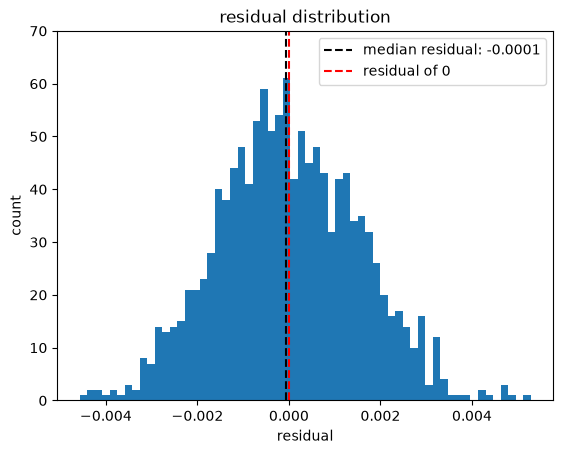

In [863]:
plt.hist(residual, bins = 60)

median_r = np.median(residual)

plt.vlines(median_r, ymin = 0, ymax = 80, color = 'black', linestyle = '--', label = f'median residual: {median_r:.4f}')
plt.vlines(0, ymin = 0, ymax = 80, color = 'red', linestyle = '--', label = 'residual of 0')
plt.title('residual distribution')
plt.xlabel('residual')
plt.ylabel('count')
plt.legend()
plt.ylim([0, 70])

A failure for this check would be if my residuals weren't centered. Since they are centered, this assumption is valid to be used.
Additionlly, the Ai mentioned resampling the detrend would be improper as it would destroy the transit structure. I wanted to visually see if this was the case.

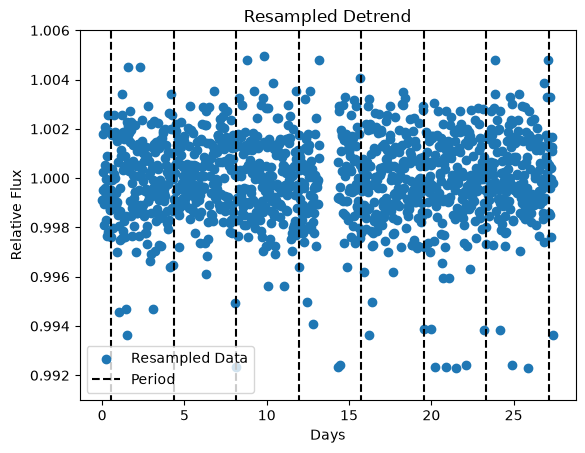

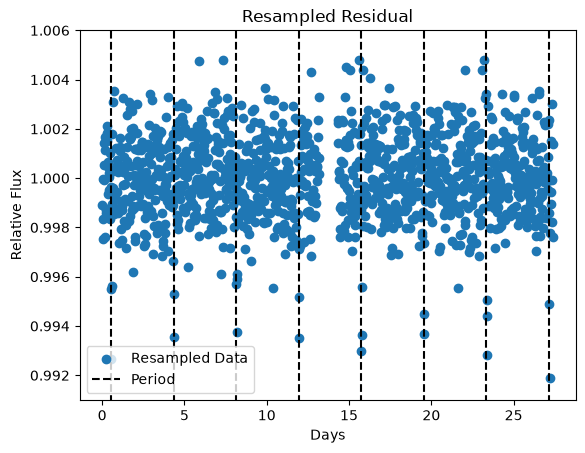

In [875]:
plt.figure(1)

resamped_mod = np.random.choice(detrend, len(detrend), replace = True)

plt.title('Resampled Detrend')
plt.xlabel('Days')
plt.ylabel('Relative Flux')
plt.scatter(t, resamped_mod)

val = .542

while val < 28:
    plt.vlines(val, ymin = .99, ymax = 1.1, color = 'black', linestyle = '--')
    val += 3.8

plt.ylim([.991, 1.006])
plt.legend(['Resampled Data', 'Period'])

plt.figure(2)

resampled_residuals = np.random.choice(residual, len(residual), replace = True)
flux_boot = model_opt + resampled_residuals

plt.scatter(t, flux_boot)
plt.title('Resampled Residual')
plt.xlabel('Days')
plt.ylabel('Relative Flux')

val = .542

while val < 28:
    plt.vlines(val, ymin = .99, ymax = 1.1, color = 'black', linestyle = '--')
    val += 3.8

plt.ylim([.991, 1.006])
plt.legend(['Resampled Data', 'Period'])

A failure for this check would be if the data moves significantly away from the period while a succuss would be if the structure remains. Looking at this resampleing, you can visually see that resampling the detrend directly fails this test while a residual resampling does not. Resampling the detrend causes the data to complete shift away from any of period lines and become scattered about the 27.4 day period. Conversly, while resampling the residuals causes the points to move up and down in relative brightness, the overall structure is preserved and the transits aren't eaten.

**VERIFICATION PLAN:**

*To help verify my process beyond what I did above, I did an order of magnitude check on simulated data.*

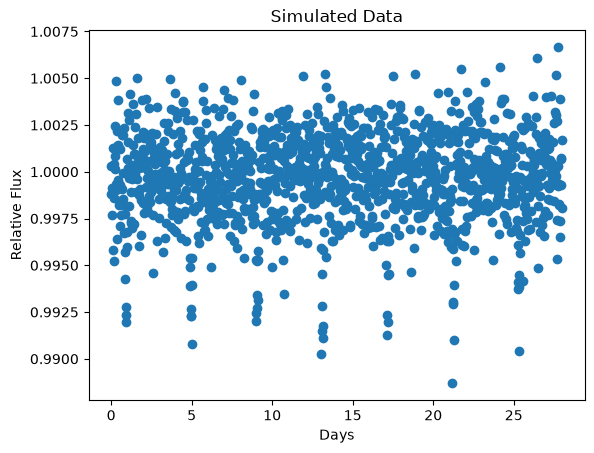

In [1017]:
t_ver = np.linspace(0, 28, 28*24*2)
model_ver = transit_model(t_ver, .9, 4.07, .0065, 5/24, 1.0, ingress_frac=0.2)

for i in range(len(model_ver)):
    model_ver[i] += np.random.normal(scale = .002)

plt.title('Simulated Data')
plt.xlabel('Days')
plt.ylabel('Relative Flux')
plt.scatter(t_ver, model_ver)

In [1009]:
theta0 = [.8, 4.0, .006, .19, 1.0003]
result = minimize(neg_log_likelihood, theta0, args=(t_ver, model_ver, .1101), method='Nelder-Mead')
t0_opt, P_opt, Depth_opt, Duration_opt, baseline_opt = result.x
result_opt = result.x

model_opt = transit_model(t_ver, t0_opt, P_opt, Depth_opt, Duration_opt, baseline_opt, ingress_frac=0.2)

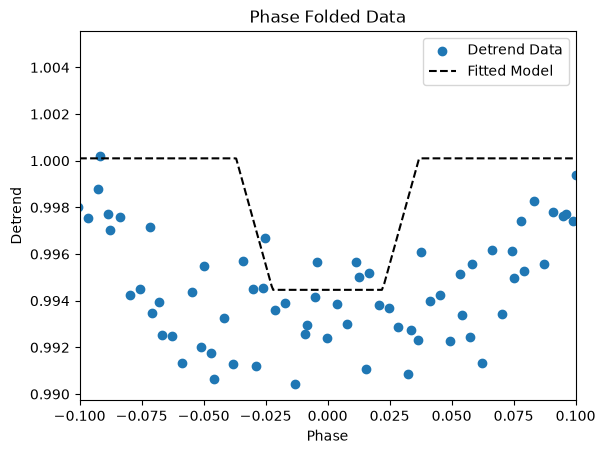

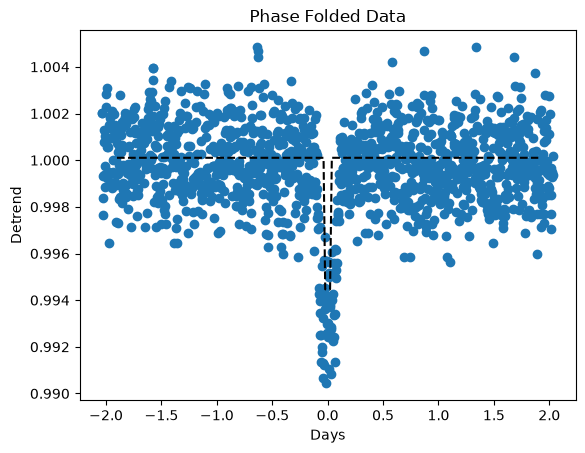

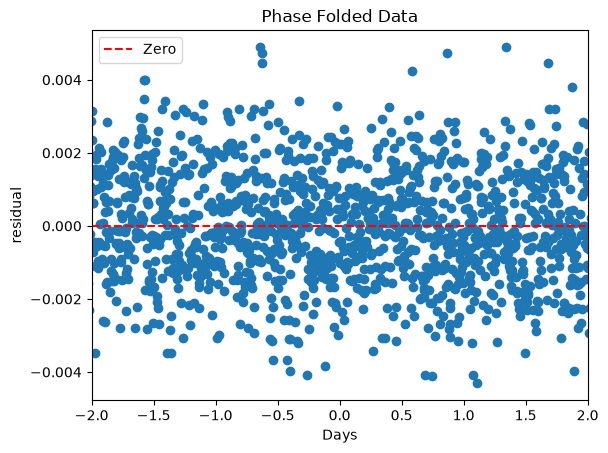

In [1010]:
plt.figure(1)

phase = ((t_ver - t0_opt + .5 * P_opt) % P_opt) - 0.5 * P_opt

idx = np.argsort(phase)
phase_sort = phase[idx]
flux_sort = model_ver[idx]
model_sort = model_opt[idx]

plt.scatter(phase_sort, flux_sort, label = 'Detrend Data')
plt.plot(p_sort, m_sort, color = 'black', linestyle = '--', label = 'Fitted Model')
plt.title('Phase Folded Data')
plt.xlabel('Phase')
plt.ylabel('Detrend')
plt.xlim([-.1, .1])
plt.legend()

plt.figure(2)

plt.scatter(phase_sort, flux_sort, label = 'Detrend Data')
plt.plot(p_sort, m_sort, color = 'black', linestyle = '--', label = 'Fitted Model')
plt.title('Phase Folded Data')
plt.xlabel('Days')
plt.ylabel('Detrend')

plt.figure(3)
residual = flux_sort - model_sort
plt.scatter(phase_sort, residual)
plt.title('Phase Folded Data')
plt.xlabel('Days')
plt.ylabel('residual')
plt.hlines(0, xmin = -2, xmax = 2, color = 'red', linestyle = '--', label = 'Zero')
plt.xlim([-2, 2])
plt.legend()

In [1011]:
blocks = []

for i in range(27):
    blocks.append(residual[48*i : 48*i + 48])

In [1014]:
t0_block_boot_a = np.zeros(2000)
P_block_boot_a = np.zeros(2000)
Depth_block_boot_a = np.zeros(2000)
Duration_block_boot_a = np.zeros(2000)
Baseline_block_boot_a = np.zeros(2000)

for i in range(2000):

    block_data = []
    
    while len(block_data) < (28*24*2):
        r = np.random.randint(0, len(blocks))
        block_data.extend(blocks[r])
    
    block_array = np.array(block_data)
    flux_block_boot = transit_model(t_ver, t0_opt, P_opt, Depth_opt, Duration_opt, baseline_opt, ingress_frac=0.2) + block_array[:(28*24*2)]

    theta = [.8, 4.0, .006, .19, 1.0003]
    
    block_boot_result = minimize(neg_log_likelihood, theta, args=(t_ver, model_ver, .1101), method='Nelder-Mead')
    t0_block_boot, P_block_boot, Depth_block_boot, Duration_block_boot, baseline_block_boot = block_boot_result.x
    
    t0_block_boot_a[i] = t0_block_boot
    P_block_boot_a[i] = P_block_boot
    Depth_block_boot_a[i] = Depth_block_boot
    Duration_block_boot_a[i] = Duration_block_boot
    Baseline_block_boot_a[i] = baseline_block_boot

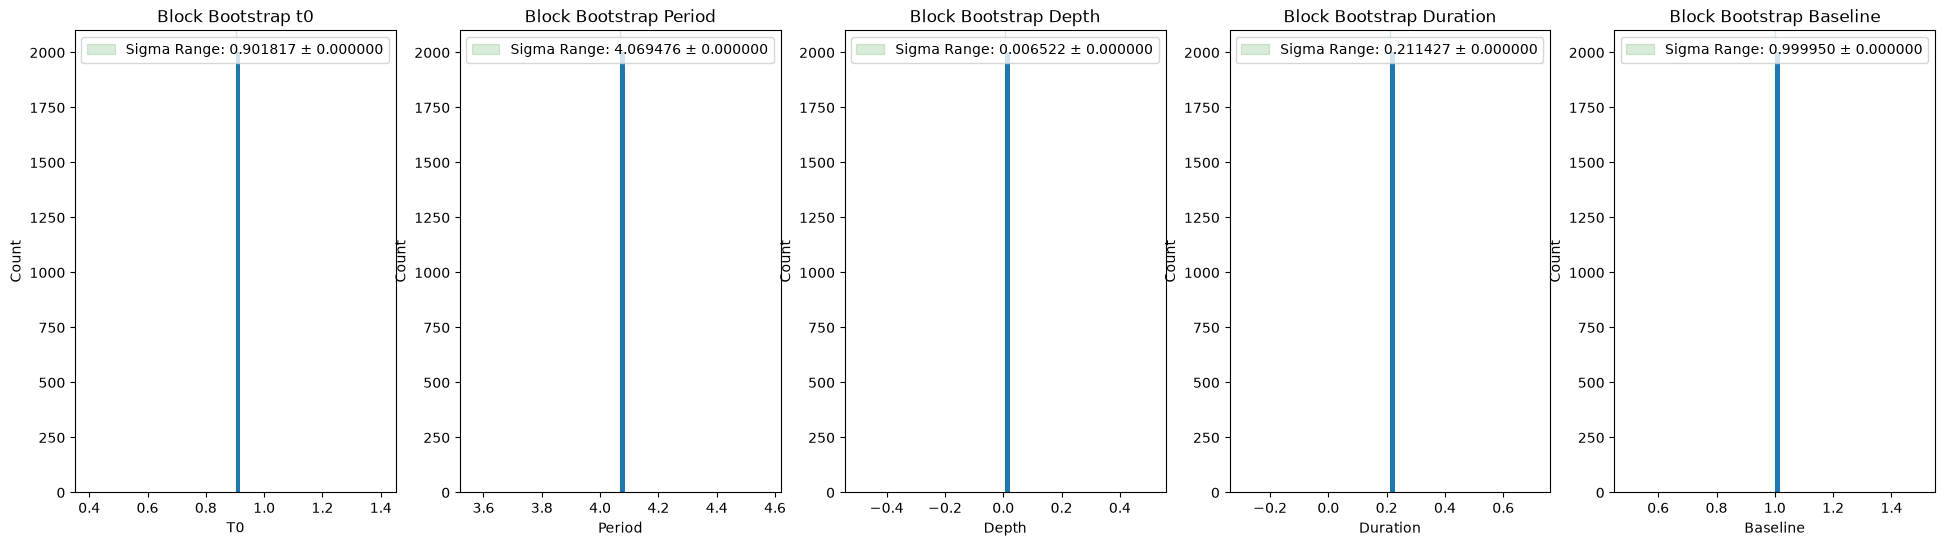

In [1015]:
plt.figure(figsize = (24, 6))
plt.subplot(1, 5, 1)
plt.hist(t0_block_boot_a, bins = 60)

lo_t0_block, hi_t0_block = np.percentile(t0_block_boot_a, [16, 84])
pw_t0_block_s = (hi_t0_block - lo_t0_block)/2
plt.axvspan(lo_t0_block, hi_t0_block, color = 'green', alpha = .15, label = f'Sigma Range: {np.median(t0_block_boot_a):.6f} \u00B1 {pw_t0_block_s:.6f}')

plt.title('Block Bootstrap t0')
plt.xlabel('T0')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 5, 2)
plt.hist(P_block_boot_a, bins = 60)

lo_P_block, hi_P_block = np.percentile(P_block_boot_a, [16, 84])
pw_P_block_s = (hi_P_block - lo_P_block)/2
plt.axvspan(lo_P_block, hi_P_block, color = 'green', alpha = .15, label = f'Sigma Range: {np.median(P_block_boot_a):.6f} \u00B1 {pw_P_block_s:.6f}')

plt.title('Block Bootstrap Period')
plt.xlabel('Period')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 5, 3)
plt.hist(Depth_block_boot_a, bins = 60)


lo_Dep_block, hi_Dep_block = np.percentile(Depth_block_boot_a, [16, 84])
pw_Dep_block_s = (hi_Dep_block - lo_Dep_block)/2
plt.axvspan(lo_Dep_block, hi_Dep_block, color = 'green', alpha = .15, label = f'Sigma Range: {np.median(Depth_block_boot_a):.6f} \u00B1 {pw_Dep_block_s:.6f}')

plt.title('Block Bootstrap Depth')
plt.xlabel('Depth')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 5, 4)
plt.hist(Duration_block_boot_a, bins = 60)

lo_Dur_block, hi_Dur_block = np.percentile(Duration_block_boot_a, [16, 84])
pw_Dur_block_s = (hi_Dur_block - lo_Dur_block)/2
plt.axvspan(lo_Dur_block, hi_Dur_block, color = 'green', alpha = .15, label = f'Sigma Range: {np.median(Duration_block_boot_a):.6f} \u00B1 {pw_Dur_block_s:.6f}')

plt.title('Block Bootstrap Duration')
plt.xlabel('Duration')
plt.ylabel('Count')
plt.legend()

plt.subplot(1, 5, 5)
plt.hist(Baseline_block_boot_a, bins = 60)

lo_bas_block, hi_bas_block = np.percentile(Baseline_block_boot_a, [16, 84])
pw_bas_block_s = (hi_bas_block - lo_bas_block)/2
plt.axvspan(lo_bas_block, hi_bas_block, color = 'green', alpha = .15, label = f'Sigma Range: {np.median(Baseline_block_boot_a):.6f} \u00B1 {pw_bas_block_s:.6f}')

plt.title('Block Bootstrap Baseline')
plt.xlabel('Baseline')
plt.ylabel('Count')
plt.legend()

To help verify that my model worked correctly I ran my simulation on simulated data. A failure for this would look like if my optimizer did not pick out the values that I chose to model the data as by a significant (order of magnitude) amount. After running my process on the data I get values that are all less than 1 magnitude away from the model I created. This is a success as all the optimizer was able to pick out the shape, and converge to something that the model I had it test on. One note, this optimization yields a number of convergent values and it doesn't provide the uncertanties of the data. This is to be expected. My simulated data just adds raw noise to every point. It does not include the correlated noise factor as this component would be much harder to input into the data without better knowledge of how a transit system affects the data. 